In [1]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import scanpy as sc
import anndata
import pandas as pd
from collections import defaultdict

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available
Number of GPUs: 1
GPU Name: NVIDIA A100-PCIE-40GB


In [2]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 6
n_var = 250
n_components = 10
n_datapoints = 50000
locs_range = 2
batch_size = 32

In [3]:
import torch
from torch.distributions import constraints
from torch.distributions.utils import (
    broadcast_all,
    lazy_property,
    logits_to_probs,
    probs_to_logits,
)
from torch.nn.functional import softplus

from pyro.distributions import LogNormal, TorchDistribution
from pyro.distributions.util import broadcast_shape

class DiscretePositiveZeroInflatedDistribution(TorchDistribution):
    """
    Generic Zero Inflated distribution.

    This can be used directly or can be used as a base class as e.g. for
    :class:`ZeroInflatedPoisson` and :class:`ZeroInflatedNegativeBinomial`.

    :param TorchDistribution base_dist: the base distribution.
    :param torch.Tensor gate: probability of extra zeros given via a Bernoulli distribution.
    :param torch.Tensor gate_logits: logits of extra zeros given via a Bernoulli distribution.
    """

    arg_constraints = {
        "gate": constraints.unit_interval,
        "gate_logits": constraints.real,
    }

    def __init__(self, base_dist, *, gate=None, gate_logits=None, validate_args=None):
        if (gate is None) == (gate_logits is None):
            raise ValueError(
                "Either `gate` or `gate_logits` must be specified, but not both."
            )
        if gate is not None:
            batch_shape = broadcast_shape(gate.shape, base_dist.batch_shape)
            self.gate = gate.expand(batch_shape)
        else:
            batch_shape = broadcast_shape(gate_logits.shape, base_dist.batch_shape)
            self.gate_logits = gate_logits.expand(batch_shape)
        if base_dist.event_shape:
            raise ValueError(
                "ZeroInflatedDistribution expected empty "
                "base_dist.event_shape but got {}".format(base_dist.event_shape)
            )

        self.base_dist = base_dist.expand(batch_shape)
        event_shape = torch.Size()

        super().__init__(batch_shape, event_shape, validate_args)

    @constraints.dependent_property
    def support(self):
        return self.base_dist.support

    @lazy_property
    def gate(self):
        return logits_to_probs(self.gate_logits, is_binary=True)

    @lazy_property
    def gate_logits(self):
        return probs_to_logits(self.gate, is_binary=True)

    def log_prob(self, value):
        if self._validate_args:
            self._validate_sample(value)

        if "gate" in self.__dict__:
            gate, value = broadcast_all(self.gate, value)
            log_prob = (-gate).log1p() + self.base_dist.log_prob(value)
            log_prob = torch.where(value == 0, gate.log(), log_prob)
        else:
            gate_logits, value = broadcast_all(self.gate_logits, value)
            log_prob_minus_log_gate = -gate_logits + self.base_dist.log_prob(value+1e-12)
            log_gate = -softplus(-gate_logits)
            log_prob = log_prob_minus_log_gate + log_gate
            #zero_log_prob = softplus(log_prob_minus_log_gate) + log_gate
            log_prob = torch.where(value == 0., log_gate, log_prob)#Replaced zero_log_prob with log_gate as log prob is nan at 0 for LN
        return log_prob

    def sample(self, sample_shape=torch.Size()):
        shape = self._extended_shape(sample_shape)
        with torch.no_grad():
            mask = torch.bernoulli(self.gate.expand(shape)).bool()
            samples = self.base_dist.expand(shape).sample()
            samples = torch.where(mask, samples.new_zeros(()), samples)
        return samples

    @lazy_property
    def mean(self):
        return (1 - self.gate) * self.base_dist.mean

    @lazy_property
    def variance(self):
        return (1 - self.gate) * (
            self.base_dist.mean**2 + self.base_dist.variance
        ) - (self.mean) ** 2

    def expand(self, batch_shape, _instance=None):
        new = self._get_checked_instance(type(self), _instance)
        batch_shape = torch.Size(batch_shape)
        gate = self.gate.expand(batch_shape) if "gate" in self.__dict__ else None
        gate_logits = (
            self.gate_logits.expand(batch_shape)
            if "gate_logits" in self.__dict__
            else None
        )
        base_dist = self.base_dist.expand(batch_shape)
        DiscretePositiveZeroInflatedDistribution.__init__(
            new, base_dist, gate=gate, gate_logits=gate_logits, validate_args=False
        )
        new._validate_args = self._validate_args
        return new

class ZeroInflatedLogNormal(DiscretePositiveZeroInflatedDistribution):
    """
    A Zero Inflated LogNormal distribution with left truncation.

    :param torch.Tensor loc: location parameter of the LogNormal distribution.
    :param torch.Tensor scale: scale parameter of the LogNormal distribution.
    :param torch.Tensor cutoff: cutoff value for truncation.
    :param torch.Tensor gate: probability of extra zeros.
    :param torch.Tensor gate_logits: logits of extra zeros.
    """

    arg_constraints = {
        "loc": constraints.real,
        "scale": constraints.positive,
        "gate": constraints.unit_interval,
        "gate_logits": constraints.real,
    }
    support = constraints.nonnegative

    def __init__(self, loc, scale, cutoff, *, gate=None, gate_logits=None, validate_args=None):
        
        # Calculate adjusted parameters
        gate_logits = -torch.logit(torch.clamp(torch.distributions.Normal(loc, scale).cdf(cutoff),min=1e-15,max=(1-1e-15)))
        #gate_logits = torch.clamp(gate_logits,min=-16., max=16.).float()
        base_dist = torch.distributions.LogNormal(loc=loc, scale=scale, validate_args=False)
        base_dist._validate_args = validate_args
        base_dist.support = constraints.nonnegative

        super().__init__(
            base_dist, gate=gate, gate_logits=gate_logits, validate_args=validate_args
        )

    @property
    def loc(self):
        return self.base_dist.loc

    @property
    def scale(self):
        return self.base_dist.scale


In [4]:
grads=defaultdict(list)

import pyro
import pyro.ops.jit
from pyro.distributions.util import is_identically_zero
from pyro.infer.elbo import ELBO
from pyro.infer.enum import get_importance_trace
from pyro.infer.util import (
    MultiFrameTensor,
    get_plate_stacks,
    is_validation_enabled,
    torch_item,
)
from pyro.util import check_if_enumerated, warn_if_nan


class SafeSVI(pyro.infer.abstract_infer.TracePosterior):
    '''A version of pyro.infer.SVI that skips steps with loss more than X sigma from the running mean loss'''
    def __init__(
        self,
        model,
        guide,
        optim,
        loss,
        loss_and_grads=None,
        clip_std_multiplier=6.0,
        window_size=1000,  # Default window size of 300
        **kwargs
    ):
        super().__init__(**kwargs)
        self.model = model
        self.guide = guide
        self.optim = optim
        self.record = False
        self.clip_std_multiplier = clip_std_multiplier
        self.window_size = window_size
        self.losses = []  # Store recent losses to calculate running stats

        if not isinstance(optim, pyro.optim.PyroOptim):
            raise ValueError("Optimizer should be an instance of pyro.optim.PyroOptim class.")

        if isinstance(loss, ELBO):
            self.loss = loss.loss
            self.loss_and_grads = loss.loss_and_grads
        else:
            if loss_and_grads is None:
                def _loss_and_grads(*args, **kwargs):
                    loss_val = loss(*args, **kwargs)
                    if getattr(loss_val, "requires_grad", False):
                        loss_val.backward(retain_graph=True)
                    return loss_val
                self.loss_and_grads = _loss_and_grads
            else:
                self.loss_and_grads = loss_and_grads

    def _traces(self, *args, **kwargs):
        for i in range(self.num_samples):
            guide_trace = poutine.trace(self.guide).get_trace(*args, **kwargs)
            model_trace = poutine.trace(
                poutine.replay(self.model, trace=guide_trace)
            ).get_trace(*args, **kwargs)
            yield model_trace, 1.0

    def evaluate_loss(self, *args, **kwargs):
        with torch.no_grad():
            loss = self.loss(self.model, self.guide, *args, **kwargs)
            return torch_item(loss)

    def step(self, *args, **kwargs):
        # Compute loss and gradients
        with poutine.trace(param_only=True) as param_capture:
            loss = self.loss_and_grads(self.model, self.guide, *args, **kwargs)
    
        loss_val = torch_item(loss)
        self.losses.append(loss_val)
        # Keep only the last `window_size` losses
        if len(self.losses) > self.window_size:
            self.losses.pop(0)
        # Extract params early to ensure they are defined for later use
        params = set(site["value"].unconstrained() for site in param_capture.trace.nodes.values())
        
        # Calculate running mean and std only if we have enough data
        if len(self.losses) >= self.window_size:
            running_mean = np.mean(self.losses)
            running_std = np.std(self.losses)
            #print(loss, running_mean,running_std)
            if ((loss > running_mean-running_std*self.clip_std_multiplier) and (loss < running_mean+running_std*self.clip_std_multiplier)):
                # Perform optimization step
                self.optim(params)
            else:
                print('STEP SKIPPED')
        else:
            self.optim(params)
        
        if self.record:
            for name, value in pyro.get_param_store().named_parameters():
                grads[name].append(value.grad.detach().cpu().numpy())
        
        # Zero gradients
        pyro.infer.util.zero_grads(params)
    
        return loss_val

In [41]:
class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.scale=1e-4
        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(num_var=self.n_var, hidden_dims=[1000, 1000, 1000], outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)])
        self.classifier = antipode.train_utils.SimpleFFNN(in_dim=self.n_latent, hidden_dims=[1000, 1000, 1000], out_dim=self.n_components)
        self.temperature = 0.1
        
    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                l = data.sum(-1).unsqueeze(-1) + 1.
                
                # Ensure parameters are leaf tensors
                locs = pyro.param('locs', 0.2 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                transform_matrix = pyro.param('transform_matrix', 0.2 * torch.randn(self.n_latent, self.n_var, device=device))

                intercept = pyro.param('intercept', torch.zeros(self.n_components, self.n_var, device=device))
                total_counts = pyro.param('total_counts', 1 * torch.ones(self.n_var, device=device), constraint=constraints.positive)
                total_counts = total_counts+0.1
                taxon_probs=pyro.sample('taxon_probs',dist.Dirichlet(data.new_ones(data.shape[0],self.n_components),validate_args=True))
                taxon = pyro.sample("taxon",antipode.model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*data.new_ones(1),probs=taxon_probs,validate_args=True))                    
                latent = pyro.sample('latent', dist.Normal(taxon@locs, taxon@scales+1e-4).to_event(1))
                out_mu = latent @ transform_matrix + taxon @ intercept
                norm_mu=torch.nn.functional.log_softmax(out_mu,dim=-1) + l.log()-(total_counts**2)/2
                pyro.sample('obs', ZeroInflatedLogNormal(loc=norm_mu,scale=total_counts,cutoff=data.new_zeros(1),validate_args=False).to_event(1), obs=data.float())

    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                locs_mu, locs_std = self.encoder(data)
                latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std + 1e-4).to_event(1))
                taxon_probs=pyro.sample('taxon_probs',dist.Delta(antipode.model_functions.safe_softmax(self.classifier(latent),dim=-1)).to_event(1))
                taxon = pyro.sample("taxon",antipode.model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*data.new_ones(1),probs=taxon_probs,validate_args=True))

In [6]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000,locs_range=2.):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range
    scales = torch.ones(n_components, n_latent) * 0.5
    transform_matrix = 1.*torch.randn(n_latent, n_var)
    intercept = 4*torch.rand(n_components, n_var)-2.
    overall_intercept = 14*torch.rand(n_var)-7.
    data = []
    true_clusters=[]
    true_latent=[]
    for _ in range(n_datapoints):
        l = 7 + 2*torch.rand(1)
        z = torch.multinomial(weights, 1).item()
        true_clusters.append(z)
        latent = torch.normal(locs[z], scales[z])
        true_latent.append(latent)
        out_mu = latent @ transform_matrix + intercept[z] + overall_intercept
        total_counts = torch.tensor(25.0)
        logits = (torch.softmax(out_mu,dim=-1)*l.exp()).log() - torch.log(total_counts) 
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data),{'latent':true_latent,'clusters':true_clusters,'weights':weights,'locs':locs,'scales':scales,'intercept':intercept}

# Generate synthetic data
data, true_params = generate_synthetic_data(n_datapoints=n_datapoints)

In [42]:
(data>0).sum(0)

tensor([10164,  1427,  4874,     8,  7896,    71,  4879,  4224,   146,     7,
         3579,  4960, 21495, 18541, 11107, 12957,     0,  4548,     0,   299,
          194, 17452,  3791,  1924,     9, 18437,   874,     9, 10517,  7776,
            4, 20510,    24,  2575,    14,  9809,    11,   113,   269,    72,
         3197,     6,  6505,  3026,     0,  5263,  3064,  2424,   279,    48,
         6657,     3,     3,  8436,     6,  7365, 13232,    11,  2171, 19968,
           90,   495,  4862,  3643,    15, 10242, 10307,  3934,    31,  1019,
           76,  2114,  8470,  3834,    11,   435,    58,  5143,  5191,     1,
        14861,  9512,  2067,  2101,  1825,  4327,  7367,   232,    10,   713,
            1,  2412,    43,  3253,  7025,     8,  8902,    40, 20878,  3399,
           66,  5479,    11,    19,     5,  1104,  5699,     1, 24083,  2763,
          270,    41,   307,  5571,  3982,    16,   276,  7968,    11,    65,
          118,     1,  5175,   167,    44,  2019, 12190,  9444, 

<Axes: ylabel='Count'>

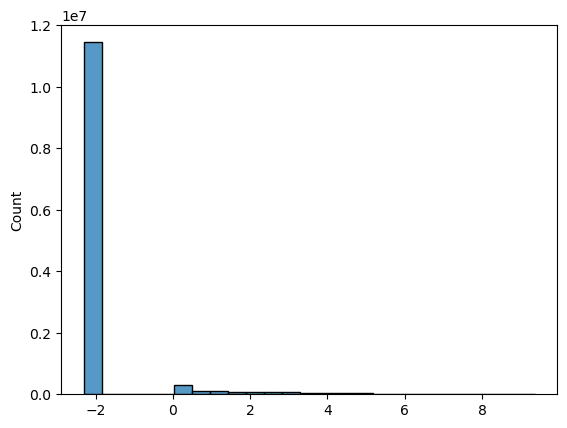

In [43]:
seaborn.histplot(np.log(data.flatten()+0.1))

<Axes: ylabel='Count'>

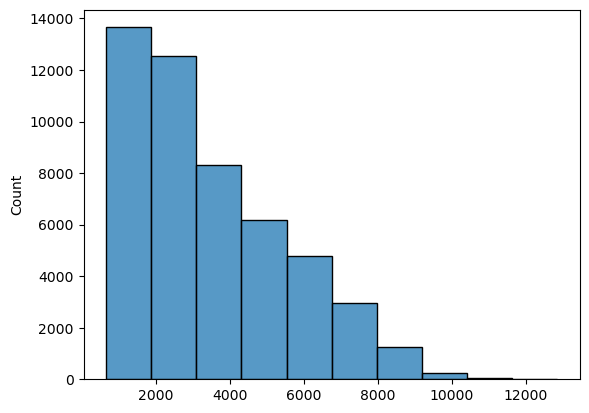

In [44]:
seaborn.histplot(data.sum(1).flatten(),bins=10)

In [45]:
adata=anndata.AnnData(X=data.cpu().numpy(),obs=pd.DataFrame([str(x) for x in true_params['clusters']],columns=['true_clusters']))
adata.obsm['true_latents']=np.stack(true_params['latent'],axis=0)

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [48]:
toy_model = ToyModel(n_latent = n_latent+5,n_var = n_var,n_components = n_components+5)
toy_model.to(device)
grads=defaultdict(list)

# SVI setup
adam_params = {"lr": 0.001}
optimizer = Adam(adam_params)
svi = SafeSVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.JitTrace_ELBO())

# Training loop
num_iterations = 30
losses = []

In [49]:
for i in tqdm.tqdm(range(num_iterations)):
    svi.record=False
    if i==num_iterations-1:
        svi.record=True
    loss = 0
    for j in range(0, n_datapoints, batch_size):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
        #if loss >0.6:
        #    print('EXPLODE KLASLKJASLDKFJALSKDJFALKSDJFLKAJSDFLKAJSDFKLJASLKDFJALKSDJFKLASDJFLKAJSDFLKJASDFLKJASLKDFJASDF')
    print(f"Iteration {i} : Loss {loss}")

print("Training complete.")

  0%|          | 0/30 [00:00<?, ?it/s]/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/pyro/distributions/util.py:231: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  elif reversed_shape[i] == 1 and not strict:
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/pyro/distributions/util.py:233: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  elif reversed_shape[i] != size and (size != 1 or strict):
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-p

In [ ]:
antipode.plotting.plot_loss(losses[5000:])

In [ ]:
pyro.param('total_counts')

In [ ]:
toy_model.eval()
latents=[]
clusters=[]
for j in range(0, n_datapoints, batch_size):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [ ]:
adata.obsm['rec_latents']=np.concatenate(latents,axis=0)
adata.obs['rec_clusters']=np.concatenate(clusters,axis=0).argmax(-1)
adata.obs['rec_clusters']=adata.obs['rec_clusters'].astype(str)

In [ ]:
adata.obsm['rec_mde']=scvi.model.utils.mde(adata.obsm['rec_latents'],init='random')
adata.obsm['true_mde']=scvi.model.utils.mde(adata.obsm['true_latents'],init='random')

In [ ]:
sc.pl.embedding(
    adata,
    basis='true_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


In [ ]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

In [ ]:
out_locs = pyro.param('locs').detach().cpu().numpy()
out_transform_matrix = pyro.param('transform_matrix').detach().cpu().numpy()
out_intercept = pyro.param('intercept').detach().cpu().numpy()

# Compute the learned cluster means
learned_means = out_locs @ out_transform_matrix + out_intercept
learned_means_clusters=[str(x) for x in range(learned_means.shape[0])]
#actual_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
actual_means = antipode.model_functions.group_aggr_anndata(adata,['rec_clusters'],normalize=True)
learned_means=learned_means[pd.Series(learned_means_clusters).isin(actual_means[1]['rec_clusters']),:]
actual_means=np.log(actual_means[0]+actual_means[0][actual_means[0]>0].min()*0.9)

In [ ]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), pyro.param('total_counts').cpu().log().detach().numpy(), alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Log Theta')
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(learned_means.flatten(),actual_means.flatten(),s=0.3)
plt.ylabel('actual')
plt.xlabel('learned')
plt.show()


In [ ]:
zdw_grads=np.absolute(np.stack(grads['transform_matrix'])).mean(0)

In [ ]:
seaborn.scatterplot(x=actual_means.mean(0),y=np.log(zdw_grads.mean(0)),s=1)
plt.xlabel('variable mean')
plt.ylabel('mean |gradient|')